## 1. Initialize Project Environment
Import libraries for network visualization.

In [10]:
from __future__ import annotations

import logging
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

# Set style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10

print("matplotlib", plt.matplotlib.__version__)
print("networkx", nx.__version__)

matplotlib 3.9.4
networkx 3.3


## 2. Define Configuration Parameters
Centralize visualization settings.

In [11]:
@dataclass
class VizConfig:
    adjacency_file: Path = Path("artifacts/task2_adjacency_matrix.csv")
    modules_file: Path = Path("artifacts/task3_module_assignments.csv")
    hub_file: Path = Path("artifacts/task3_hub_genes.csv")
    tom_file: Path = Path("artifacts/task3_tom_matrix.csv")
    export_dir: Path = Path("artifacts")
    edge_threshold: float = 0.05  # Only show strong edges
    node_size_base: int = 100
    hub_size_multiplier: float = 3.0
    fig_dpi: int = 150

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        for k in [
            "adjacency_file",
            "modules_file",
            "hub_file",
            "tom_file",
            "export_dir",
        ]:
            info[k] = str(info[k])
        return info


CONFIG = VizConfig()
CONFIG.describe()

{'adjacency_file': 'artifacts/task2_adjacency_matrix.csv',
 'modules_file': 'artifacts/task3_module_assignments.csv',
 'hub_file': 'artifacts/task3_hub_genes.csv',
 'tom_file': 'artifacts/task3_tom_matrix.csv',
 'export_dir': 'artifacts',
 'edge_threshold': 0.05,
 'node_size_base': 100,
 'hub_size_multiplier': 3.0,
 'fig_dpi': 150}

## 3. Load Data
Load adjacency matrix, module assignments, and hub gene information.

In [12]:
# Load data
adjacency = pd.read_csv(CONFIG.adjacency_file, index_col=0)
modules = pd.read_csv(CONFIG.modules_file)
hubs = pd.read_csv(CONFIG.hub_file)
tom = pd.read_csv(CONFIG.tom_file, index_col=0)

logging.info(f"Loaded adjacency: {adjacency.shape}")
logging.info(f"Loaded {len(modules)} module assignments")
logging.info(f"Loaded {hubs['IsHub'].sum()} hub genes")

# Create gene -> module mapping
gene_to_module = dict(zip(modules["Gene"], modules["Module"]))

# Create gene -> hub status mapping
gene_to_hub = dict(zip(hubs["Gene"], hubs["IsHub"]))

[INFO] Loaded adjacency: (67, 67)
[INFO] Loaded 67 module assignments
[INFO] Loaded 7 hub genes


## 4. Build NetworkX Graph
Create a graph from the adjacency matrix with edge weights.

In [13]:
def build_graph(adj: pd.DataFrame, edge_threshold: float = 0.01) -> nx.Graph:
    """
    Build NetworkX graph from adjacency matrix.
    Only include edges above threshold.
    """
    G = nx.Graph()
    G.add_nodes_from(adj.index)

    # Add edges
    for i, gene_i in enumerate(adj.index):
        for j, gene_j in enumerate(adj.columns):
            if i < j:
                weight = adj.iloc[i, j]
                if weight > edge_threshold:
                    G.add_edge(gene_i, gene_j, weight=weight)

    # Remove isolates
    isolates = list(nx.isolates(G))
    G.remove_nodes_from(isolates)

    logging.info(
        f"Built graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges"
    )
    logging.info(f"Removed {len(isolates)} isolated nodes")

    return G


G = build_graph(adjacency, CONFIG.edge_threshold)
print(f"\nGraph statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")

[INFO] Built graph: 67 nodes, 1475 edges
[INFO] Removed 0 isolated nodes



Graph statistics:
  Nodes: 67
  Edges: 1475
  Density: 0.6671


## 5. Network Visualization with Module Colors
Visualize the full network with nodes colored by module and hub genes highlighted.

/tmp/ipykernel_35622/1664462570.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


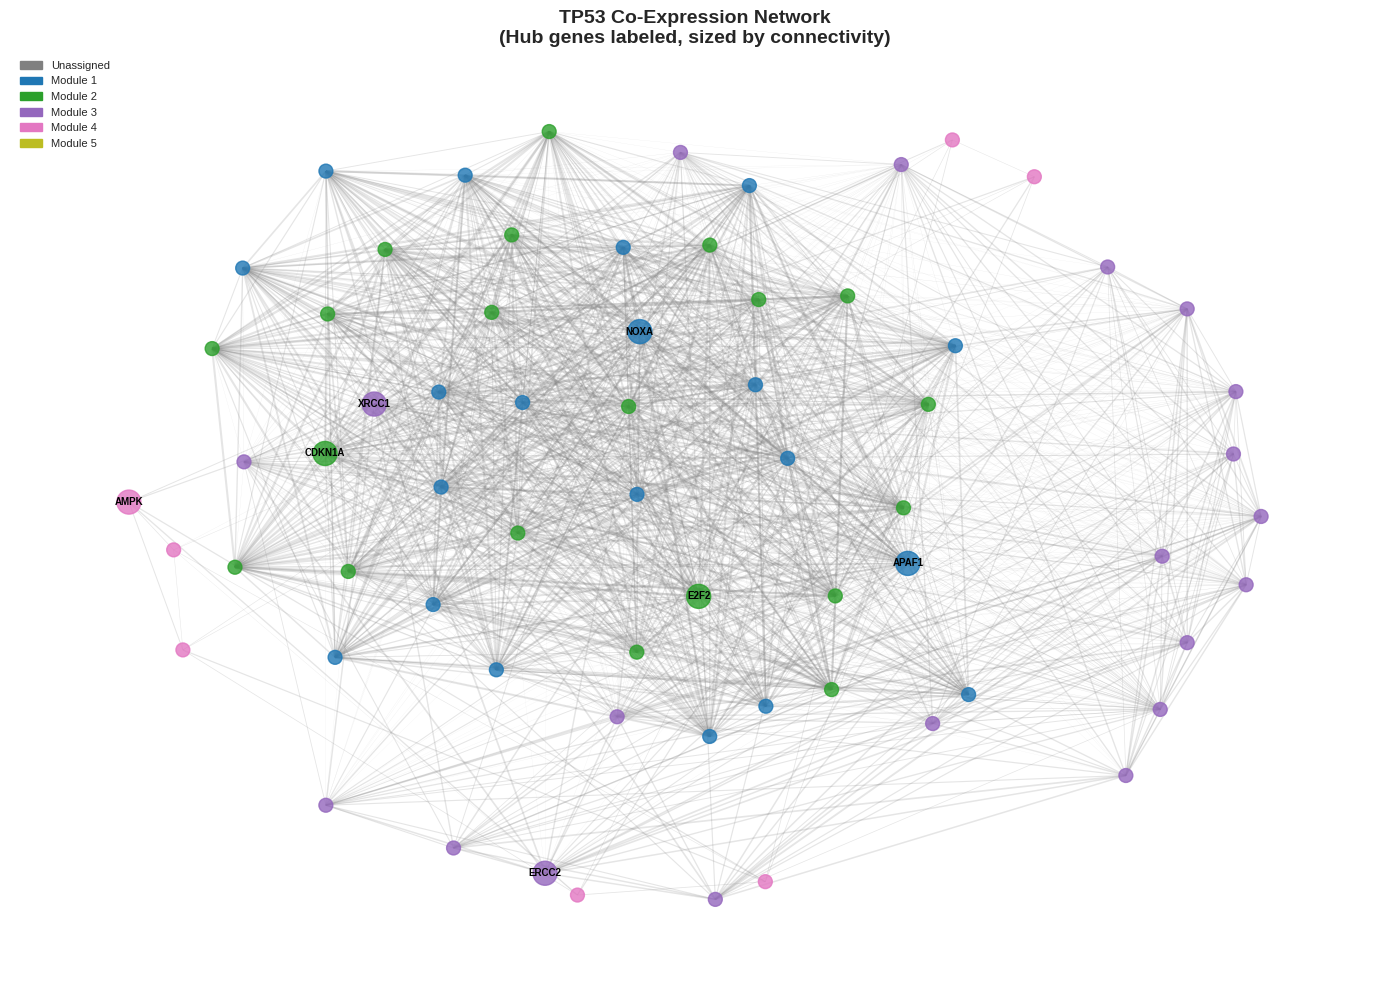

In [14]:
def get_module_colors(n_modules: int) -> Dict[int, str]:
    """Generate distinct colors for modules."""
    # Use a colormap for distinct colors
    cmap = plt.cm.get_cmap("tab20")
    colors = {}
    colors[0] = "#808080"  # Grey for unassigned
    for i in range(1, n_modules + 1):
        colors[i] = cmap((i - 1) / max(n_modules, 1))
    return colors


def visualize_network(
    G: nx.Graph,
    gene_to_module: Dict[str, int],
    gene_to_hub: Dict[str, bool],
    cfg: VizConfig,
    title: str = "Gene Co-Expression Network",
) -> plt.Figure:
    """
    Visualize network with module coloring and hub highlighting.
    """
    fig, ax = plt.subplots(figsize=(14, 10))

    # Get module colors
    n_modules = max(gene_to_module.values()) + 1
    module_colors = get_module_colors(n_modules)

    # Node colors and sizes
    node_colors = []
    node_sizes = []
    node_labels = {}

    for node in G.nodes():
        module = gene_to_module.get(node, 0)
        is_hub = gene_to_hub.get(node, False)

        node_colors.append(module_colors[module])

        if is_hub:
            node_sizes.append(cfg.node_size_base * cfg.hub_size_multiplier)
            node_labels[node] = node  # Label hub genes
        else:
            node_sizes.append(cfg.node_size_base)

    # Layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Draw edges (thin and transparent)
    edge_weights = [G[u][v].get("weight", 0.1) for u, v in G.edges()]
    nx.draw_networkx_edges(
        G, pos, alpha=0.2, width=[w * 2 for w in edge_weights], edge_color="grey", ax=ax
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax
    )

    # Draw labels for hub genes only
    nx.draw_networkx_labels(
        G, pos, labels=node_labels, font_size=7, font_weight="bold", ax=ax
    )

    # Legend
    legend_patches = []
    for module, color in sorted(module_colors.items()):
        if module == 0:
            label = "Unassigned"
        else:
            label = f"Module {module}"
        legend_patches.append(mpatches.Patch(color=color, label=label))

    ax.legend(handles=legend_patches, loc="upper left", fontsize=8)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

    plt.tight_layout()
    return fig


fig_network = visualize_network(
    G,
    gene_to_module,
    gene_to_hub,
    CONFIG,
    title="TP53 Co-Expression Network\n(Hub genes labeled, sized by connectivity)",
)
plt.show()

## 6. Module-Specific Visualization
Visualize individual modules with their hub genes.

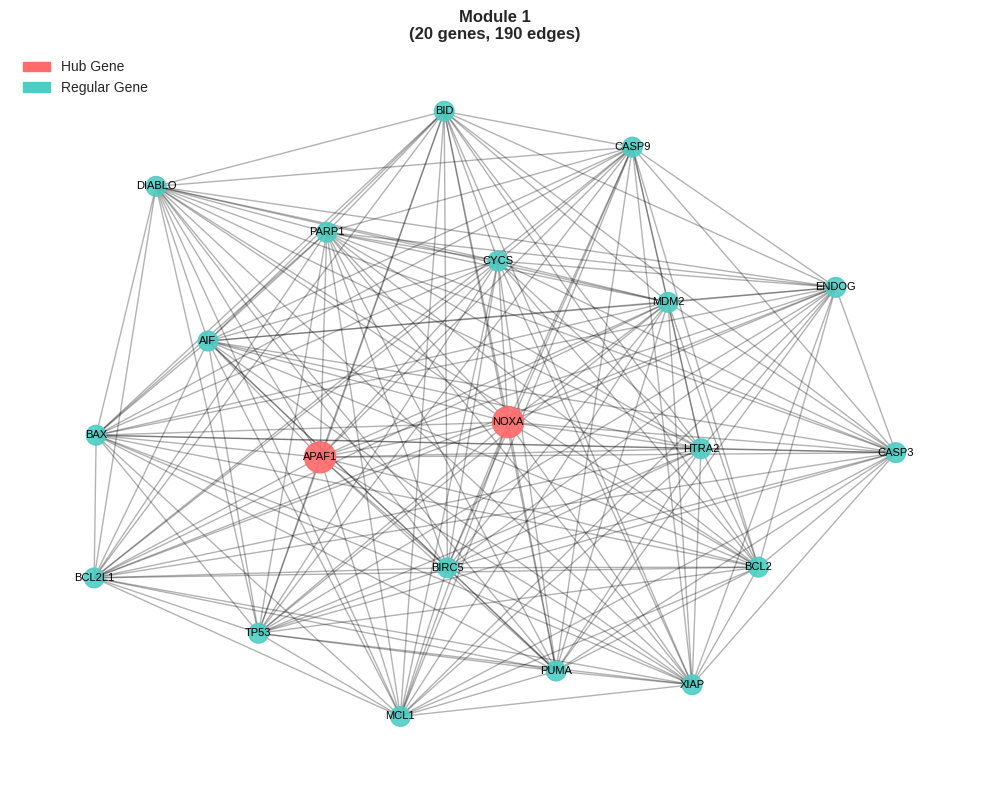

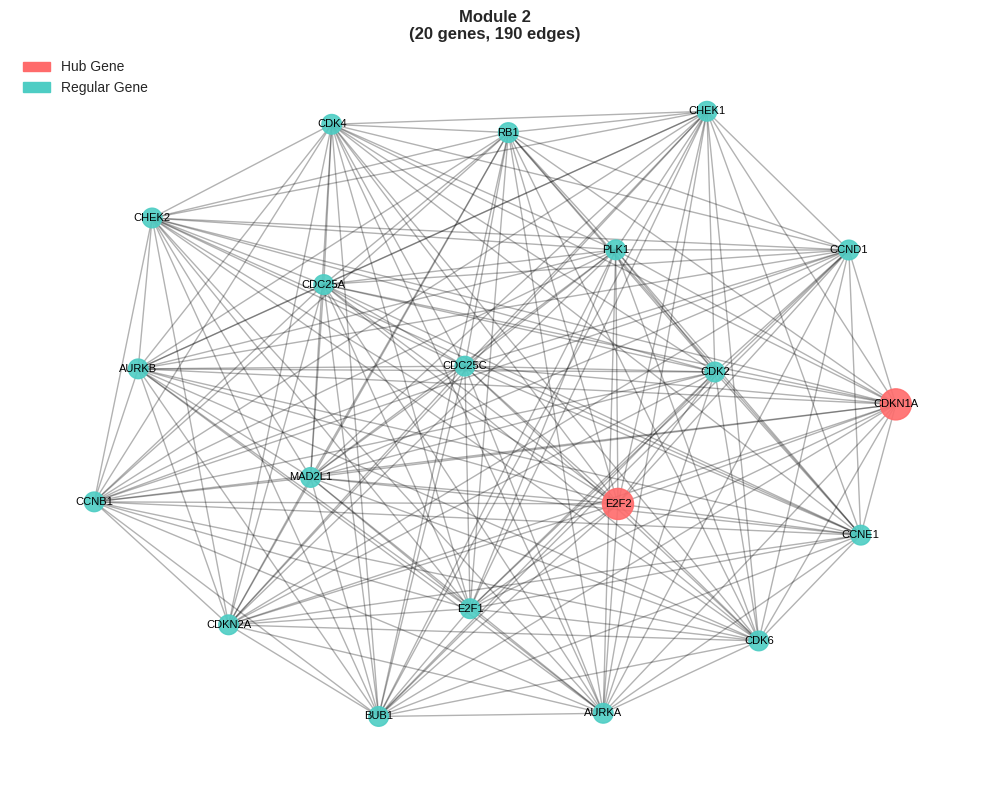

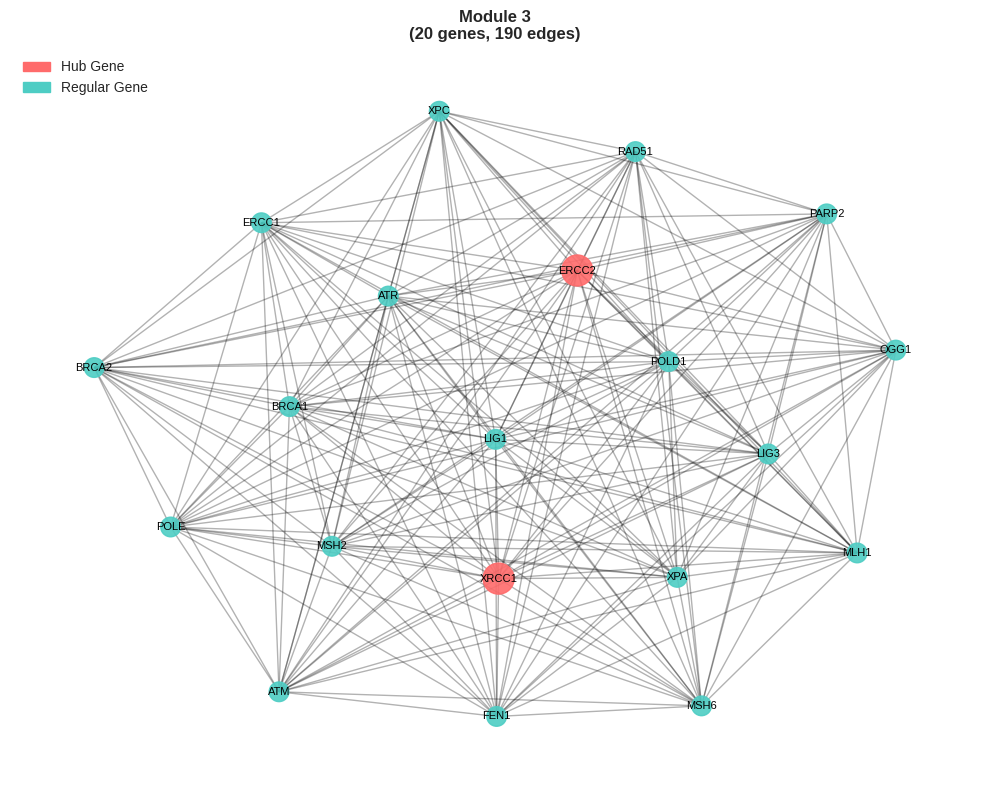

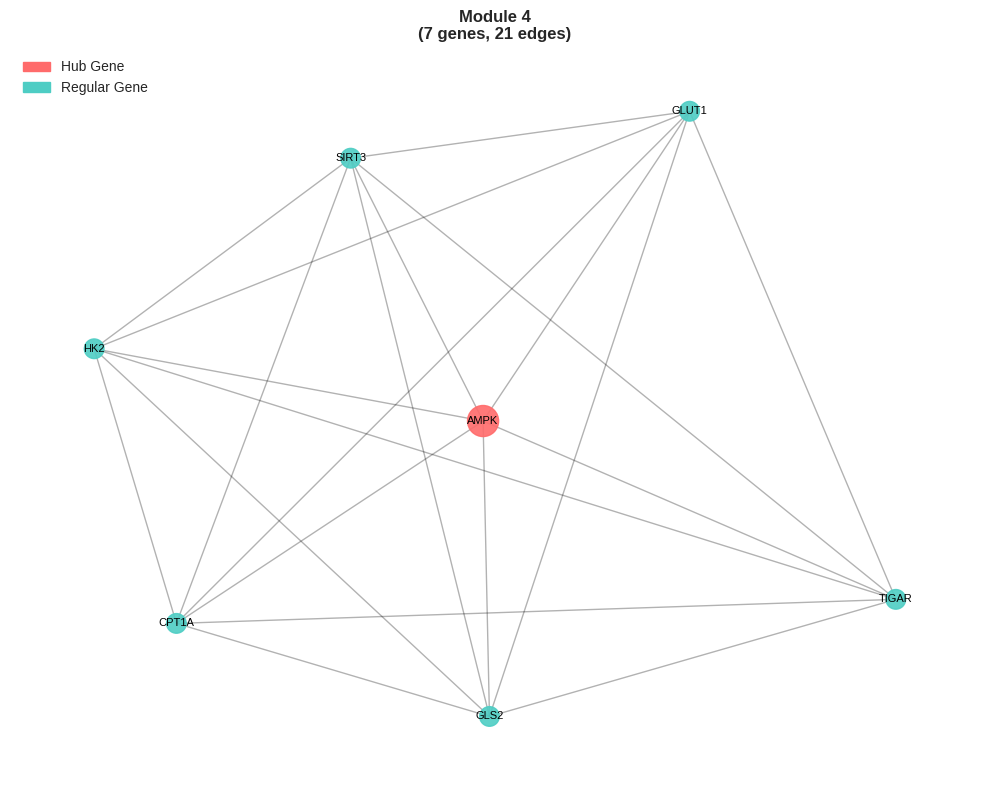

In [15]:
def visualize_module(
    G: nx.Graph,
    gene_to_module: Dict[str, int],
    gene_to_hub: Dict[str, bool],
    target_module: int,
    cfg: VizConfig,
) -> plt.Figure:
    """
    Visualize a specific module with all genes labeled.
    """
    # Get genes in target module
    module_genes = [
        g for g, m in gene_to_module.items() if m == target_module and g in G.nodes()
    ]

    if len(module_genes) < 2:
        logging.warning(f"Module {target_module} has fewer than 2 genes in graph")
        return None

    # Create subgraph
    subG = G.subgraph(module_genes).copy()

    fig, ax = plt.subplots(figsize=(10, 8))

    # Node properties
    node_colors = []
    node_sizes = []

    for node in subG.nodes():
        is_hub = gene_to_hub.get(node, False)
        if is_hub:
            node_colors.append("#ff6b6b")  # Red for hubs
            node_sizes.append(500)
        else:
            node_colors.append("#4ecdc4")  # Teal for regular
            node_sizes.append(200)

    pos = nx.spring_layout(subG, k=1.5, seed=42)

    # Draw
    nx.draw_networkx_edges(subG, pos, alpha=0.3, width=1, ax=ax)
    nx.draw_networkx_nodes(
        subG, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax
    )
    nx.draw_networkx_labels(subG, pos, font_size=8, ax=ax)

    # Legend
    legend_patches = [
        mpatches.Patch(color="#ff6b6b", label="Hub Gene"),
        mpatches.Patch(color="#4ecdc4", label="Regular Gene"),
    ]
    ax.legend(handles=legend_patches, loc="upper left")

    ax.set_title(
        f"Module {target_module}\n({len(module_genes)} genes, {subG.number_of_edges()} edges)",
        fontsize=12,
        fontweight="bold",
    )
    ax.axis("off")

    plt.tight_layout()
    return fig


# Visualize the largest modules
module_sizes = modules["Module"].value_counts().sort_values(ascending=False)
top_modules = [m for m in module_sizes.index if m != 0][:4]  # Top 4 non-zero modules

for module_id in top_modules:
    fig = visualize_module(G, gene_to_module, gene_to_hub, module_id, CONFIG)
    if fig:
        plt.show()

## 7. Dendrogram Visualization
Show hierarchical clustering structure from TOM dissimilarity.

/tmp/ipykernel_35622/1664462570.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


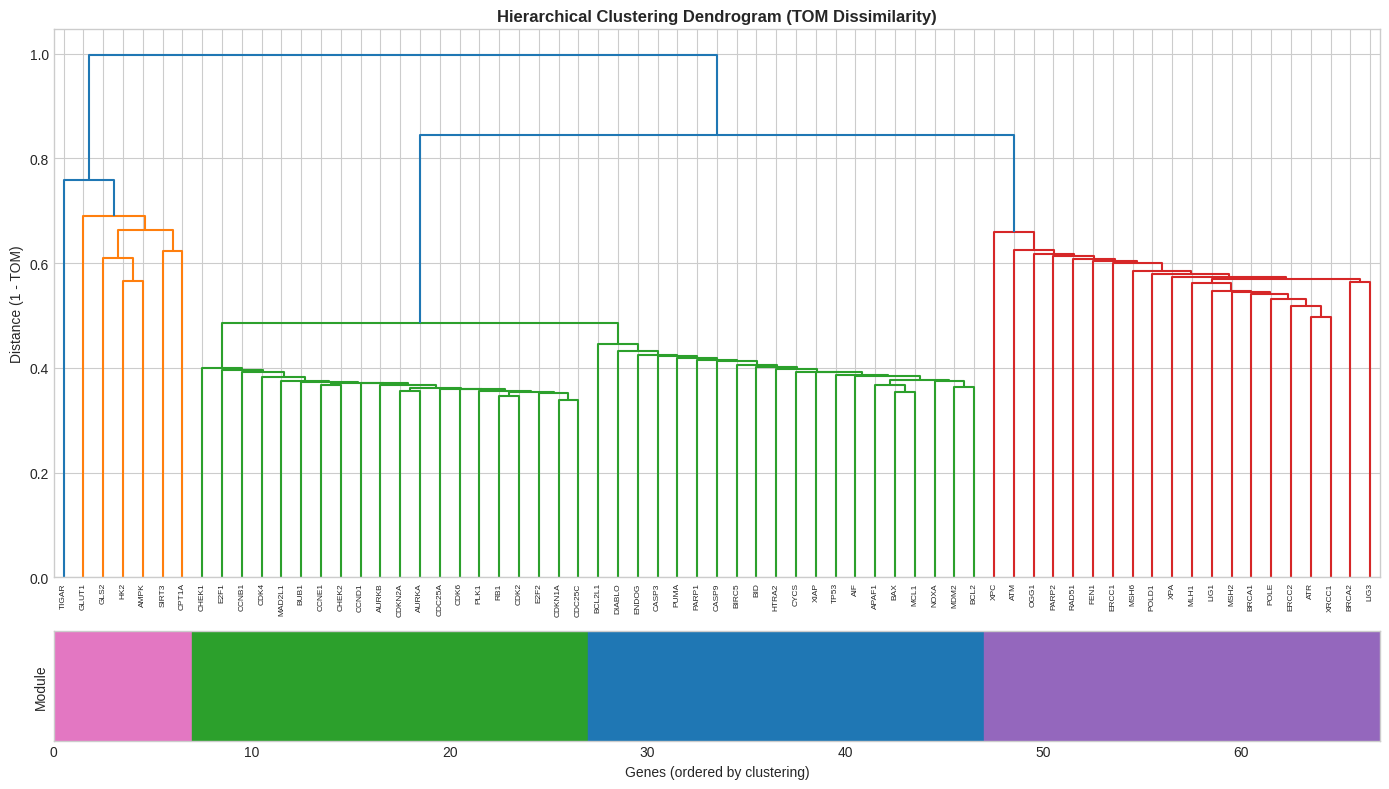

In [16]:
def plot_dendrogram_with_modules(
    tom: pd.DataFrame, gene_to_module: Dict[str, int], method: str = "average"
) -> plt.Figure:
    """
    Plot dendrogram with module color bar.
    """
    # Convert TOM to dissimilarity
    dissim = 1 - tom.values
    np.fill_diagonal(dissim, 0)
    dissim_condensed = squareform(dissim)

    # Hierarchical clustering
    Z = linkage(dissim_condensed, method=method)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [5, 1]}
    )

    # Dendrogram
    dendro = dendrogram(
        Z,
        labels=tom.index.tolist(),
        ax=ax1,
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=0.7 * max(Z[:, 2]),
    )
    ax1.set_title(
        "Hierarchical Clustering Dendrogram (TOM Dissimilarity)",
        fontsize=12,
        fontweight="bold",
    )
    ax1.set_ylabel("Distance (1 - TOM)")

    # Module color bar
    n_modules = max(gene_to_module.values()) + 1
    module_colors = get_module_colors(n_modules)

    # Get leaf order from dendrogram
    leaf_order = dendro["leaves"]
    genes_ordered = [tom.index[i] for i in leaf_order]

    # Create color array for module bar
    colors = [module_colors[gene_to_module.get(g, 0)] for g in genes_ordered]

    # Plot color bar
    for i, color in enumerate(colors):
        ax2.axvspan(i, i + 1, color=color)

    ax2.set_xlim(0, len(genes_ordered))
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Genes (ordered by clustering)")
    ax2.set_ylabel("Module")
    ax2.set_yticks([])

    plt.tight_layout()
    return fig


fig_dendro = plot_dendrogram_with_modules(tom, gene_to_module)
plt.show()

## 8. Correlation Heatmap
Visualize the correlation matrix ordered by module.

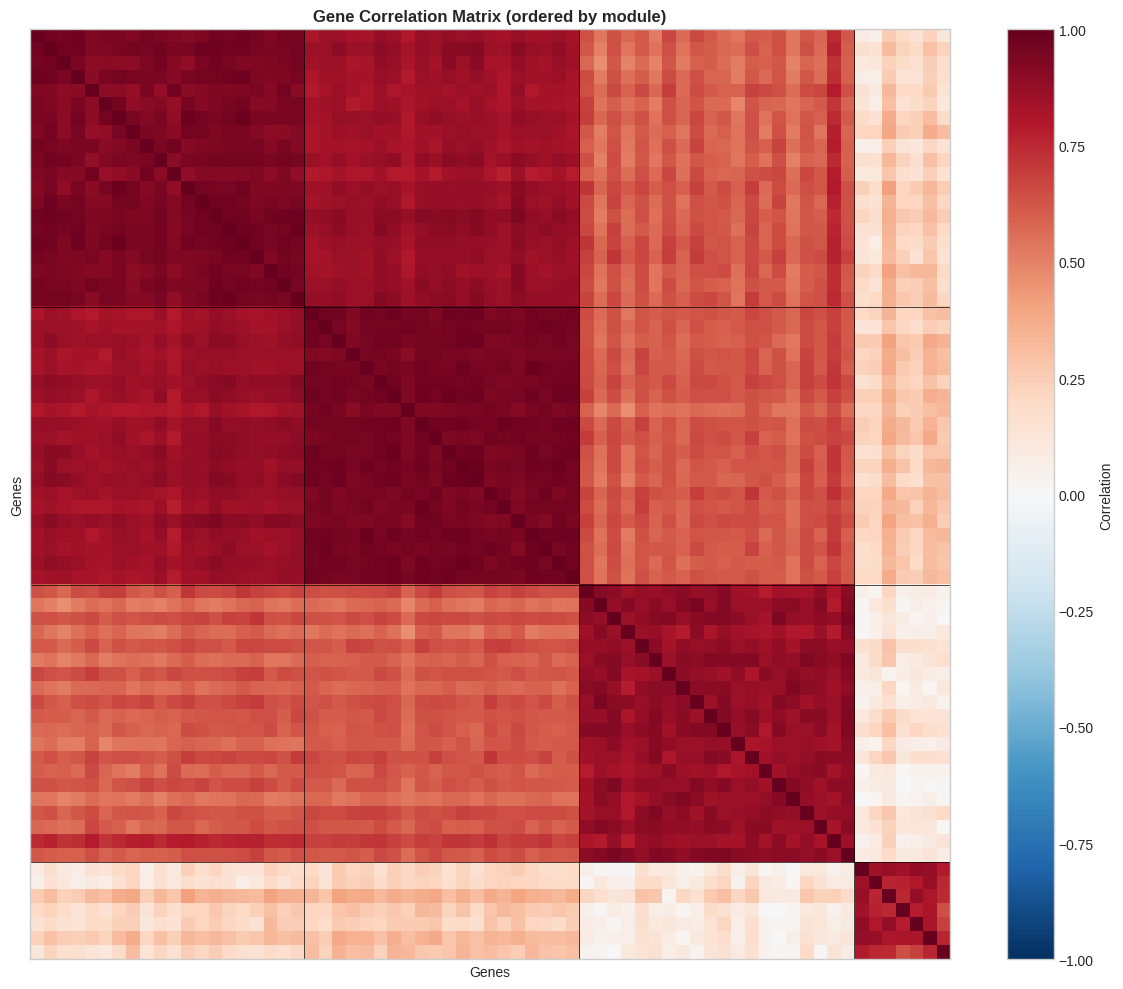

In [17]:
def plot_correlation_heatmap(
    corr_file: Path, gene_to_module: Dict[str, int]
) -> plt.Figure:
    """
    Plot correlation heatmap with genes ordered by module.
    """
    corr = pd.read_csv(corr_file, index_col=0)

    # Order genes by module
    gene_order = sorted(corr.index, key=lambda g: (gene_to_module.get(g, 99), g))
    corr_ordered = corr.loc[gene_order, gene_order]

    fig, ax = plt.subplots(figsize=(12, 10))

    im = ax.imshow(corr_ordered.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

    # Add module boundaries
    current_module = -1
    for i, gene in enumerate(gene_order):
        module = gene_to_module.get(gene, 0)
        if module != current_module and current_module != -1:
            ax.axhline(y=i - 0.5, color="black", linewidth=0.5)
            ax.axvline(x=i - 0.5, color="black", linewidth=0.5)
        current_module = module

    plt.colorbar(im, ax=ax, label="Correlation")
    ax.set_title(
        "Gene Correlation Matrix (ordered by module)", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Genes")
    ax.set_ylabel("Genes")

    # Reduce tick density
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    return fig


fig_heatmap = plot_correlation_heatmap(
    Path("artifacts/task2_correlation_matrix.csv"), gene_to_module
)
plt.show()

## 9. Export Visualizations
Save all figures to artifacts folder.

In [18]:
EXPORT_DIR = CONFIG.export_dir
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save full network
fig_network = visualize_network(
    G, gene_to_module, gene_to_hub, CONFIG, title="TP53 Co-Expression Network"
)
fig_network.savefig(
    EXPORT_DIR / "task4_network_full.png", dpi=CONFIG.fig_dpi, bbox_inches="tight"
)
print(f"[OK] Full network saved to: {EXPORT_DIR / 'task4_network_full.png'}")
plt.close(fig_network)

# Save module visualizations
for i, module_id in enumerate(top_modules[:2]):  # Save top 2 modules
    fig = visualize_module(G, gene_to_module, gene_to_hub, module_id, CONFIG)
    if fig:
        fig.savefig(
            EXPORT_DIR / f"task4_module_{module_id}.png",
            dpi=CONFIG.fig_dpi,
            bbox_inches="tight",
        )
        print(
            f"[OK] Module {module_id} saved to: {EXPORT_DIR / f'task4_module_{module_id}.png'}"
        )
        plt.close(fig)

# Save dendrogram
fig_dendro = plot_dendrogram_with_modules(tom, gene_to_module)
fig_dendro.savefig(
    EXPORT_DIR / "task4_dendrogram.png", dpi=CONFIG.fig_dpi, bbox_inches="tight"
)
print(f"[OK] Dendrogram saved to: {EXPORT_DIR / 'task4_dendrogram.png'}")
plt.close(fig_dendro)

# Save heatmap
fig_heatmap = plot_correlation_heatmap(
    Path("artifacts/task2_correlation_matrix.csv"), gene_to_module
)
fig_heatmap.savefig(
    EXPORT_DIR / "task4_correlation_heatmap.png",
    dpi=CONFIG.fig_dpi,
    bbox_inches="tight",
)
print(
    f"[OK] Correlation heatmap saved to: {EXPORT_DIR / 'task4_correlation_heatmap.png'}"
)
plt.close(fig_heatmap)

print("\n[OK] All visualizations exported successfully!")

/tmp/ipykernel_35622/1664462570.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


[OK] Full network saved to: artifacts/task4_network_full.png
[OK] Module 1 saved to: artifacts/task4_module_1.png
[OK] Module 2 saved to: artifacts/task4_module_2.png


/tmp/ipykernel_35622/1664462570.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


[OK] Dendrogram saved to: artifacts/task4_dendrogram.png
[OK] Correlation heatmap saved to: artifacts/task4_correlation_heatmap.png

[OK] All visualizations exported successfully!
